**1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR.

**

In [31]:
import pandas as pd
import numpy as np

In [32]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [33]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [35]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [36]:
df.duplicated().sum()

np.int64(1)

In [37]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
num_cols=df.select_dtypes(include='int').columns
cat_cols=df.select_dtypes(include='object').columns


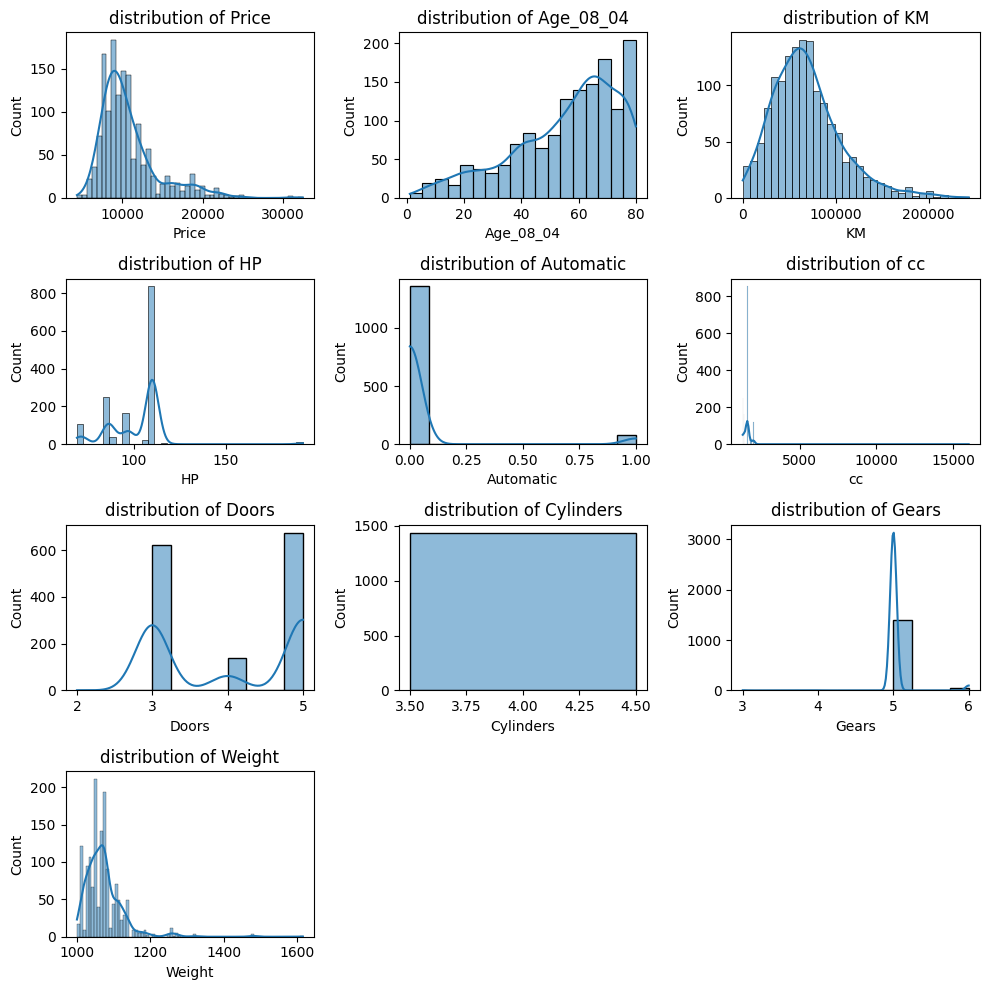

In [12]:
plt.figure(figsize=(10,10))
for i,col in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col],kde=True)
    plt.title(f'distribution of {col}')




plt.tight_layout()
plt.show()

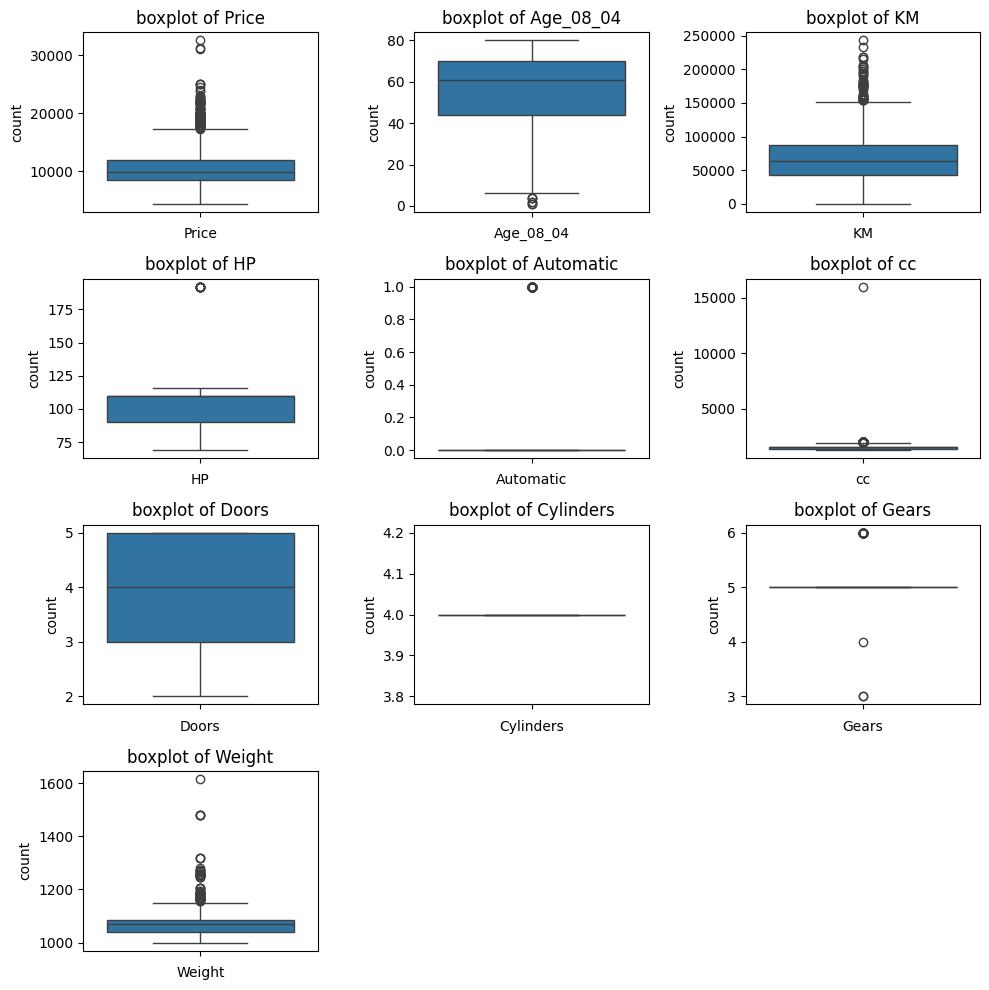

In [13]:
plt.figure(figsize=(10,10))
for i,col in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(df[col])
    plt.title(f'boxplot of {col}')
    plt.xlabel(col)
    plt.ylabel('count')

plt.tight_layout()
plt.show()

In [14]:
df=pd.get_dummies(df,columns=['Fuel_Type'],drop_first=True)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


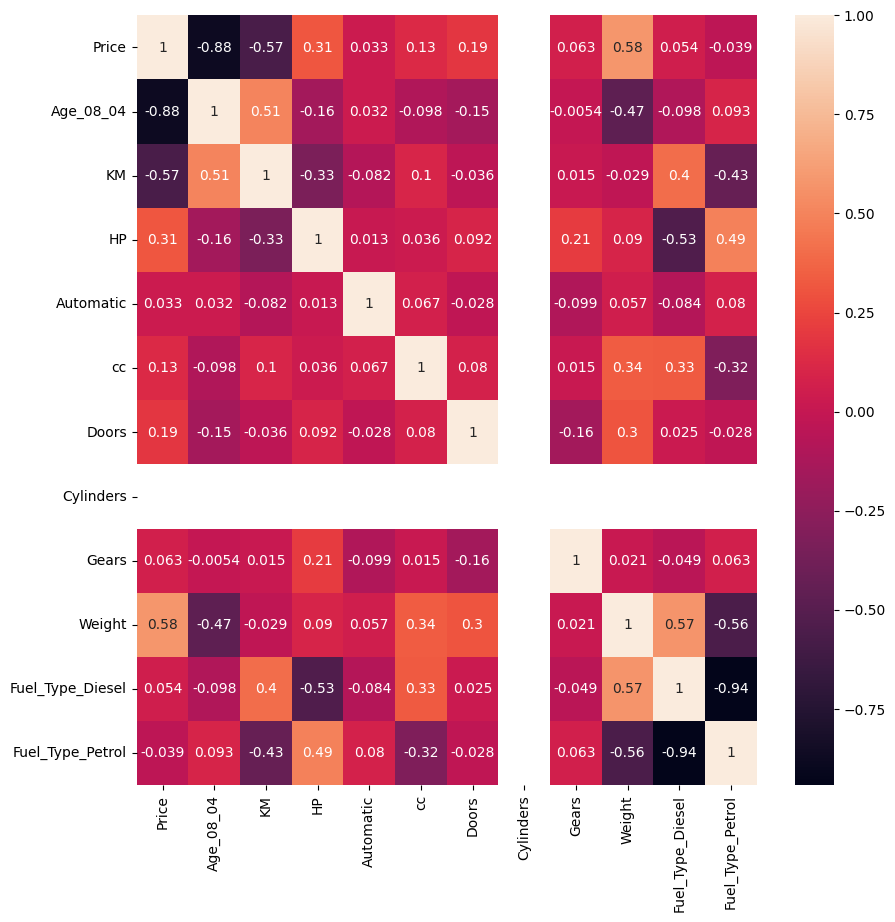

In [15]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

**.
2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

**

In [16]:
x=df.drop('Price',axis=1)
y=df['Price']

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)


In [18]:
print('x_train:',x_train.shape)
print('x_test:',x_test.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)

x_train: (1148, 11)
x_test: (288, 11)
y_train: (1148,)
y_test: (288,)


**
3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build minimum of 3 different models.
**

In [19]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
print(f'lr.coef_:{lr.coef_}')
print(f'lr.intercept_:{lr.intercept_}')

lr.coef_:[-1.20830458e+02 -1.62314106e-02  1.40394788e+01  1.48830927e+02
 -3.03721946e-02 -6.03109744e+01 -1.62003744e-12  5.51600710e+02
  2.58849583e+01 -6.85487568e+01  1.37080891e+03]
lr.intercept_:-14255.385993565254


In [53]:
print('interpret coeffeicents of linear regression')
for name,coef in zip(x.columns,lr.coef_):
    print(f'{name}:{coef}')

interpret coeffeicents of linear regression
Age_08_04:-120.83045817097117
KM:-0.016231410612674253
HP:14.039478769759068
Automatic:148.83092691181997
cc:-0.030372194607027406
Doors:-60.31097437498872
Cylinders:-1.6200374375330284e-12
Gears:551.6007102659818
Weight:25.884958313274495
Fuel_Type_Diesel:-68.54875675828677
Fuel_Type_Petrol:1370.80890981598


**
5.Apply Lasso and Ridge methods on the model.
**

In [20]:
from sklearn.linear_model import Ridge,Lasso
ridge=Ridge()
ridge.fit(x_train,y_train)
print(f'ridge.coef_:{ridge.coef_}')
print(f'ridge.intercept_:{ridge.intercept_}')


ridge.coef_:[-1.20779659e+02 -1.63240795e-02  1.41418340e+01  1.46907470e+02
 -3.05094386e-02 -5.99057913e+01  0.00000000e+00  5.42272328e+02
  2.58210194e+01 -1.28813072e+02  1.29494983e+03]
ridge.intercept_:-14075.037871589753


In [54]:
print('interpret coeffeicents of ridge regression')
for name,coef in zip(x.columns,ridge.coef_):
    print(f'{name}:{coef}')

interpret coeffeicents of ridge regression
Age_08_04:-120.77965945868493
KM:-0.016324079542572006
HP:14.141834012008527
Automatic:146.90746971608866
cc:-0.030509438556819056
Doors:-59.90579131646375
Cylinders:0.0
Gears:542.2723281414661
Weight:25.82101944161877
Fuel_Type_Diesel:-128.81307202315259
Fuel_Type_Petrol:1294.9498258986353


In [55]:
lasso=Lasso()
lasso.fit(x_train,y_train)
print(f'lasso.coef_:{lasso.coef_}')
print(f'lasso.intercept_:{lasso.intercept_}')

lasso.coef_:[-1.20798032e+02 -1.63255341e-02  1.45592200e+01  1.33401454e+02
 -3.23988246e-02 -5.86731609e+01  0.00000000e+00  5.22177477e+02
  2.57219631e+01 -3.23101256e+01  1.36439171e+03]
lasso.intercept_:-13981.559519106231


In [56]:
print('interpret coeffeicents of lasso regression')
for name,coef in zip(x.columns,lasso.coef_):
    print(f'{name}:{coef}')

interpret coeffeicents of lasso regression
Age_08_04:-120.7980320188164
KM:-0.01632553410027898
HP:14.55921996229932
Automatic:133.4014541660453
cc:-0.03239882461911515
Doors:-58.67316094777726
Cylinders:0.0
Gears:522.1774765640034
Weight:25.721963099346983
Fuel_Type_Diesel:-32.31012559539381
Fuel_Type_Petrol:1364.391707347425


In [22]:
y_pred=lr.predict(x_test)


In [23]:
y_pred_ridge=ridge.predict(x_test)

In [24]:
y_pred_lasso=lasso.predict(x_test)

In [25]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
print('r2_score:',r2_score(y_test,y_pred))
print('mean_squared_error:',mean_squared_error(y_test,y_pred))
print('mean_absolute_error:',mean_absolute_error(y_test,y_pred))
print('root_mean_squared_error:',root_mean_squared_error(y_test,y_pred))

r2_score: 0.8348888040611082
mean_squared_error: 2203043.8231437025
mean_absolute_error: 990.8872739193926
root_mean_squared_error: 1484.2654153296514


In [26]:
print('r2_score:',r2_score(y_test,y_pred_ridge))
print('mean_squared_error:',mean_squared_error(y_test,y_pred_ridge))
print('mean_absolute_error:',mean_absolute_error(y_test,y_pred_ridge))
print('root_mean_squared_error:',root_mean_squared_error(y_test,y_pred_ridge))
#

r2_score: 0.8351359377712336
mean_squared_error: 2199746.3702333393
mean_absolute_error: 990.7338342026006
root_mean_squared_error: 1483.1541963778882


In [27]:
print('r2_score:',r2_score(y_test,y_pred_lasso))
print('mean_squared_error:',mean_squared_error(y_test,y_pred_lasso))
print('mean_absolute_error:',mean_absolute_error(y_test,y_pred_lasso))
print('root_mean_squared_error:',root_mean_squared_error(y_test,y_pred_lasso))



r2_score: 0.8354626403967389
mean_squared_error: 2195387.2460865397
mean_absolute_error: 990.9546616159029
root_mean_squared_error: 1481.6839224634043


In [61]:
result={
    'linearregression':[r2_score(y_test,y_pred),mean_squared_error(y_test,y_pred),root_mean_squared_error(y_test,y_pred),mean_absolute_error(y_test,y_pred)],
    'ridgeregression':[r2_score(y_test,y_pred_ridge),mean_squared_error(y_test,y_pred_ridge),root_mean_squared_error(y_test,y_pred_ridge),mean_absolute_error(y_test,y_pred_ridge)],
    'lassoregression':[r2_score(y_test,y_pred_lasso),mean_squared_error(y_test,y_pred_lasso),root_mean_squared_error(y_test,y_pred_lasso),mean_absolute_error(y_test,y_pred_lasso)]
                  }

In [64]:
print(result)

   model        r2         mae           mse         rmse
0     lr  0.834889  990.887274  2.203044e+06  1484.265415
1  ridge  0.835136  990.733834  2.199746e+06  1483.154196
2  lasso  0.835463  990.954662  2.195387e+06  1481.683922


# Interview Questions:

**1.What is Normalization & Standardization and how is it helpful?**

**normalization :**

it is a preprocessing techique which the numerical data is transformed in between 0 to 1

**standardization:**
transforms data to have a mean of 0 and a standard deviation of 1.

these normalization and standardization data helps for further model building processs

**2.What techniques can be used to address multicollinearity in multiple linear regression?**

Multicollinearity occurs in a multiple linear regression model when two or more predictor variables are highly correlated with each other.

techniques:

collecting more data

using lasso and ridge regression models

combining highly correlated predicted values
